# Day 01：金鱼记忆 —— 为什么神经网络看完就忘？> ⏳ 第九周 · 记忆的诞生 · 第 1 天到目前为止，我们认识的所有神经网络都有一个致命缺陷：**它们没有记忆。**一个 CNN 看图片，看完就忘。你给它看"我 爱 深 度 学 习"这五个字，它把每个字单独看一遍，却完全不知道"深度"和"学习"之间有什么关系。这就像一个只有 3 秒记忆的金鱼——每一刻都是全新的，上一秒发生的事，下一秒就忘了。**今天的任务**：1. 理解前馈网络的"无记忆"困境2. 认识序列数据——为什么顺序很重要3. 用代码证明：打乱顺序后，模型就懵了---

## 1. 历史剧场：深度学习的"失忆症"2010 年代初，深度学习在图像识别上大杀四方（AlexNet、VGGNet、ResNet），但在自然语言处理（NLP）上却举步维艰。为什么？因为语言是**有序的**。> "狗咬人" vs "人咬狗"同样的三个字，顺序不同，意思天差地别。但 CNN 根本不在乎顺序——它把每个字当成独立的特征来处理。更糟糕的是句子理解：> "我出生在北京，后来搬到了上海，那里的**天气**比北京潮湿。""那里"指的是上海，不是北京。要理解这句话，你必须**记住**前面提到的信息。但 CNN 做不到——它看完"北京"就忘了，看完"上海"也忘了。这就是前馈网络的**金鱼困境**：没有记忆，就无法理解上下文。---

## 2. 生活隐喻：为什么"看完就忘"很致命？想象你在看电影：- **有记忆的观众**：看到主角拿起钥匙，想起第一幕里他找到了钥匙——"哦，他终于要开门了！"- **没有记忆的观众（金鱼观众）**：每一幕都是全新的，主角拿起钥匙？什么钥匙？他在干嘛？深度学习在 2010 年代之前，就是那个"金鱼观众"。再想象你在读一封邮件：> "会议改到**周五**了，**不要**在周一来了。"如果你只看到"周一"和"来"，你会以为周一要开会。但"不要"这个词改变了整个意思。没有上下文记忆，你根本无法正确理解。**关键洞察**：很多数据天然就是有序的——语言、音乐、股票价格、天气变化。处理这类数据，模型必须拥有"记忆"。---

<p align="center">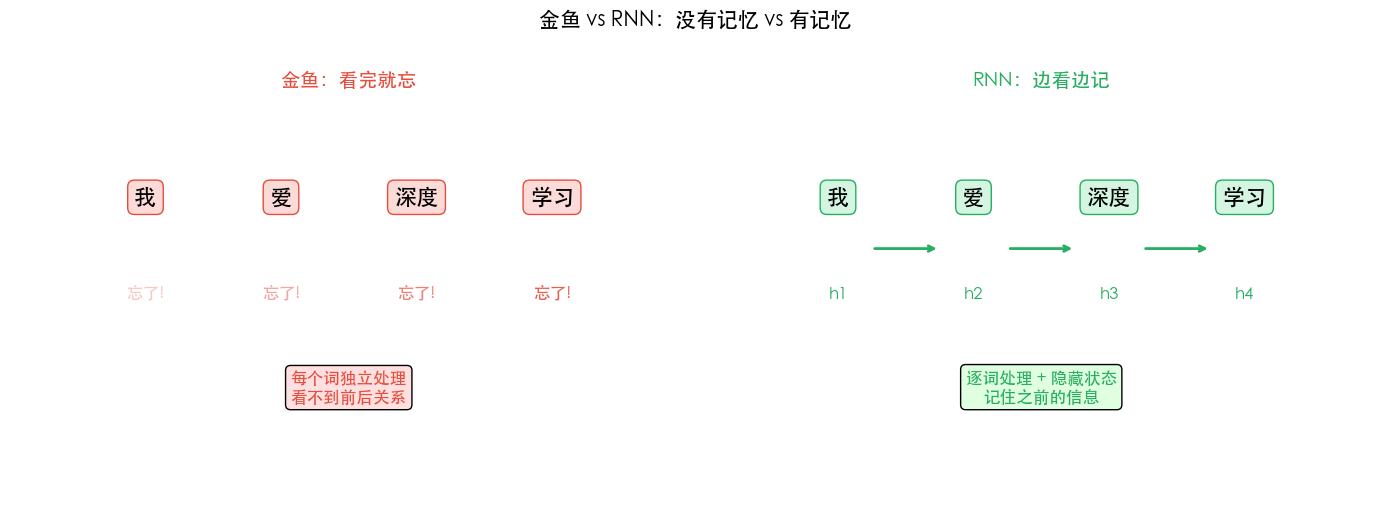</p>*金鱼记忆 vs RNN 记忆对比图*

## 3. 代码实验室：证明"顺序很重要"让我们用代码证明：打乱顺序后，模型就分不清了。

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 生成序列数据：情感分类我们构造一个简单的任务：根据词语序列判断情感（正面/负面）。

In [ ]:
word_to_idx = {    '好': 0, '棒': 1, '喜欢': 2, '开心': 3, '优秀': 4,    '差': 5, '烂': 6, '讨厌': 7, '难过': 8, '糟糕': 9,    '不': 10, '很': 11, '非常': 12}positive_sentences = [    ['好'], ['棒'], ['喜欢'], ['开心'], ['优秀'],    ['很', '好'], ['非常', '棒'], ['很', '喜欢'],    ['不', '差'], ['不', '烂']]negative_sentences = [    ['差'], ['烂'], ['讨厌'], ['难过'], ['糟糕'],    ['很', '差'], ['非常', '烂'], ['很', '讨厌'],    ['不', '好'], ['不', '棒']]def sentences_to_tensor(sentences, max_len=3):    data = []    for sent in sentences:        indices = [word_to_idx[w] for w in sent]        padded = indices + [0] * (max_len - len(indices))        data.append(padded)    return torch.tensor(data, dtype=torch.long)X_pos = sentences_to_tensor(positive_sentences)X_neg = sentences_to_tensor(negative_sentences)X_all = torch.cat([X_pos, X_neg])y_all = torch.cat([torch.ones(len(X_pos)), torch.zeros(len(X_neg))]).unsqueeze(1)print(f"数据形状: X={X_all.shape}, y={y_all.shape}")print(f"正面样本: {len(X_pos)}, 负面样本: {len(X_neg)}")

### 3.2 前馈网络：把顺序信息丢掉

In [ ]:
class FeedForwardClassifier(nn.Module):    def __init__(self, vocab_size=13, embed_dim=8, hidden_dim=16):        super().__init__()        self.embedding = nn.Embedding(vocab_size, embed_dim)        self.fc = nn.Sequential(            nn.Linear(embed_dim * 3, hidden_dim),            nn.ReLU(),            nn.Linear(hidden_dim, 1),            nn.Sigmoid()        )    def forward(self, x):        emb = self.embedding(x)        flat = emb.view(emb.size(0), -1)        return self.fc(flat)torch.manual_seed(42)ff_model = FeedForwardClassifier()optimizer = torch.optim.Adam(ff_model.parameters(), lr=0.01)loss_fn = nn.BCELoss()for epoch in range(200):    pred = ff_model(X_all)    loss = loss_fn(pred, y_all)    optimizer.zero_grad()    loss.backward()    optimizer.step()ff_acc = ((pred > 0.5).float() == y_all).float().mean()print(f"前馈网络准确率: {ff_acc:.2%}")

### 3.3 关键实验：打乱顺序

In [ ]:
X_shuffled = X_all[:, torch.randperm(3)]torch.manual_seed(42)ff_shuffled = FeedForwardClassifier()optimizer2 = torch.optim.Adam(ff_shuffled.parameters(), lr=0.01)for epoch in range(200):    pred = ff_shuffled(X_shuffled)    loss = loss_fn(pred, y_all)    optimizer2.zero_grad()    loss.backward()    optimizer2.step()shuffled_acc = ((pred > 0.5).float() == y_all).float().mean()print(f"打乱顺序后准确率: {shuffled_acc:.2%}")

### 3.4 对比结果

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))bars = ax.bar(['原始顺序', '打乱顺序'], [ff_acc.item(), shuffled_acc.item()],              color=['#27ae60', '#e74c3c'], alpha=0.8, edgecolor='black')ax.set_ylabel('准确率', fontsize=13)ax.set_title('前馈网络：打乱顺序就懵了', fontsize=15)ax.set_ylim(0, 1.1)for bar, acc in zip(bars, [ff_acc.item(), shuffled_acc.item()]):    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,            f'{acc:.2%}', ha='center', fontsize=14, fontweight='bold')ax.grid(True, alpha=0.3, axis='y')plt.tight_layout()plt.show()

### 解读注意看"不"这个字：- "不差" → 正面（否定+负面=正面）- "不好" → 负面（否定+正面=负面）"不"的含义完全取决于它**后面跟的是什么**。前馈网络把所有词同时输入，无法理解这种"先后关系"。---

## 4. 几何直觉：为什么前馈网络看不到"时间"？前馈网络处理输入的方式是：**把所有特征一次性展平，然后一起喂进去。**

"我 爱 深 度 学 习"  ↓ 展平[我, 爱, 深, 度, 学, 习] → 一个大向量 → 全连接层 → 输出

这就像把一部电影的所有帧叠在一起，变成一张模糊的合成照——你根本看不出剧情的发展。**我们需要的是**：一个能"逐帧观看"的模型——看完第一帧，记住关键信息，再看第二帧，把新信息和之前的记忆结合起来……> 这就是明天要讲的——**循环神经网络（RNN）**。---

## 今日结语今天我们发现了一个根本性的问题：前馈网络没有记忆，无法理解序列数据中的"顺序"和"上下文"。语言、音乐、股票——这些数据的核心就是"先后关系"。打乱顺序，意义就变了。我们需要一种全新的网络架构：它能**按顺序处理输入**，并在处理过程中**保留关键信息**。明天，我们将认识深度学习的第一种"有记忆"的网络——RNN。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 金鱼记忆——看完就忘 | 前馈网络——无状态，每次输入独立处理 || 电影要按顺序看 | 序列数据——顺序携带关键信息 || "不"的含义取决于上下文 | 上下文依赖——当前输入的含义依赖之前的信息 || 把所有帧叠成一张图 | 展平输入——丢失时序信息 || 逐帧观看并记住关键情节 | 循环处理——RNN 的核心思想（预告！） |